# Supervised Models — ELEC3612 Assignment 1

This notebook implements and evaluates four supervised classifiers: 
Decision Tree, Random Forest, SVM, and Logistic Regression. 

For Decision Tree and Logistic Regression we run a full robustness 
analysis varying split ratios, k-fold values, random seeds, and 
hyperparameter tuning. Random Forest and SVM are evaluated with a 
standard setup and compared against the other models.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# Load dataset
df = pd.read_csv('../data/aug_train.csv')
df = df.drop(columns=['enrollee_id'])

# Separate features and target
X = df.drop(columns=['target'])
y = df['target']

# Column types
numerical_cols = ['city_development_index', 'training_hours']
ordinal_cols = ['experience', 'last_new_job']
nominal_cols = ['city', 'gender', 'relevent_experience', 'enrolled_university',
                'education_level', 'major_discipline', 'company_size', 'company_type']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nClass distribution:\n{y.value_counts(normalize=True).round(3)}")

X shape: (19158, 12)
y shape: (19158,)

Class distribution:
target
0.0    0.751
1.0    0.249
Name: proportion, dtype: float64


## Pipeline Builder

To avoid repeating preprocessing code in every experiment, we define 
a helper function that wraps preprocessing and any given model into a 
single pipeline. This guarantees the preprocessor is always fitted only 
on training data, regardless of which experiment calls it.

In [2]:
def build_pipeline(model):
    """
    Builds a full preprocessing + model pipeline.
    Preprocessing is fitted only on training data to prevent data leakage.
    """
    numerical_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    ordinal_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
    ])
    nominal_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])
    preprocessor = ColumnTransformer([
        ('num', numerical_pipeline, numerical_cols),
        ('ord', ordinal_pipeline, ordinal_cols),
        ('nom', nominal_pipeline, nominal_cols)
    ])
    return Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

print("build_pipeline() ready")

build_pipeline() ready


## Experiment Runner

We define a helper function that takes a model, a split ratio, and a seed, 
runs the full train/test experiment, and returns all required metrics. 
This keeps the experiment code clean and consistent across all models.

In [3]:
def run_experiment(model, test_size, random_state):
    """
    Runs a single train/test experiment.
    Returns a dict with all evaluation metrics.
    """
    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=random_state
    )

    # Build and fit pipeline
    pipe = build_pipeline(model)
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    return {
        'accuracy':  accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'recall':    recall_score(y_test, y_pred, average='weighted', zero_division=0),
        'f1':        f1_score(y_test, y_pred, average='weighted', zero_division=0),
        'y_test':    y_test,
        'y_pred':    y_pred
    }

print("run_experiment() ready")

run_experiment() ready


## Decision Tree

We run a full robustness analysis on the Decision Tree, varying split 
ratios, stratified vs non-stratified splits, k-fold values, random seeds, 
and hyperparameter tuning. This is one of the two models selected for the 
required robustness analysis (the other being Logistic Regression).

In [4]:
# Decision Tree: varying split ratios and seeds
split_ratios = [0.40, 0.30, 0.20]
seeds = [42, 123]

dt_split_results = []

for seed in seeds:
    for test_size in split_ratios:
        res = run_experiment(
            DecisionTreeClassifier(random_state=seed),
            test_size=test_size,
            random_state=seed
        )
        dt_split_results.append({
            'split': f"{int((1-test_size)*100)}/{int(test_size*100)}",
            'seed': seed,
            'accuracy':  round(res['accuracy'], 4),
            'precision': round(res['precision'], 4),
            'recall':    round(res['recall'], 4),
            'f1':        round(res['f1'], 4)
        })

dt_split_df = pd.DataFrame(dt_split_results)
print("=== Decision Tree — Split Ratio & Seed Analysis ===")
print(dt_split_df.to_string(index=False))

=== Decision Tree — Split Ratio & Seed Analysis ===
split  seed  accuracy  precision  recall     f1
60/40    42    0.6986     0.7016  0.6986 0.7001
70/30    42    0.7074     0.7098  0.7074 0.7086
80/20    42    0.7035     0.7079  0.7035 0.7056
60/40   123    0.7011     0.7056  0.7011 0.7033
70/30   123    0.7138     0.7143  0.7138 0.7140
80/20   123    0.7109     0.7121  0.7109 0.7115


In [8]:
# Decision Tree: stratified vs non-stratified split
strat_results = []

for stratified in [True, False]:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, 
        stratify=y if stratified else None,
        random_state=42
    )
    pipe = build_pipeline(DecisionTreeClassifier(random_state=42))
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    
    strat_results.append({
        'split_type': 'Stratified' if stratified else 'Non-stratified',
        'class_1_pct_test': round(y_test.mean(), 4),
        'accuracy':  round(accuracy_score(y_test, y_pred), 4),
        'precision': round(precision_score(y_test, y_pred, average='weighted', zero_division=0), 4),
        'recall':    round(recall_score(y_test, y_pred, average='weighted', zero_division=0), 4),
        'f1':        round(f1_score(y_test, y_pred, average='weighted', zero_division=0), 4)
    })

strat_df = pd.DataFrame(strat_results)
print("=== Decision Tree — Stratified vs Non-Stratified ===")
print(strat_df.to_string(index=False))

=== Decision Tree — Stratified vs Non-Stratified ===
    split_type  class_1_pct_test  accuracy  precision  recall     f1
    Stratified            0.2492    0.7035     0.7079  0.7035 0.7056
Non-stratified            0.2484    0.7106     0.7133  0.7106 0.7119


In [5]:
# Decision Tree: varying k-fold CV values
k_values = [3, 5, 10]
SEED = 42

dt_cv_results = []

for k in k_values:
    pipe = build_pipeline(DecisionTreeClassifier(random_state=SEED))
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, stratify=y, random_state=SEED
    )
    
    cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=SEED)
    cv_res = cross_validate(pipe, X_train, y_train, cv=cv,
                            scoring=['accuracy', 'precision_weighted', 
                                     'recall_weighted', 'f1_weighted'],
                            n_jobs=-1)
    
    dt_cv_results.append({
        'k': k,
        'acc_mean':  round(np.mean(cv_res['test_accuracy']), 4),
        'acc_std':   round(np.std(cv_res['test_accuracy']), 4),
        'prec_mean': round(np.mean(cv_res['test_precision_weighted']), 4),
        'rec_mean':  round(np.mean(cv_res['test_recall_weighted']), 4),
        'f1_mean':   round(np.mean(cv_res['test_f1_weighted']), 4),
        'f1_std':    round(np.std(cv_res['test_f1_weighted']), 4)
    })

dt_cv_df = pd.DataFrame(dt_cv_results)
print("=== Decision Tree — K-Fold CV Analysis ===")
print(dt_cv_df.to_string(index=False))

=== Decision Tree — K-Fold CV Analysis ===
 k  acc_mean  acc_std  prec_mean  rec_mean  f1_mean  f1_std
 3    0.7000   0.0065     0.7028    0.7000   0.7013  0.0070
 5    0.7019   0.0076     0.7037    0.7019   0.7027  0.0069
10    0.7042   0.0086     0.7084    0.7042   0.7061  0.0076


In [6]:
# Decision Tree: with and without hyperparameter tuning
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

# Without tuning
pipe_no_tuning = build_pipeline(DecisionTreeClassifier(random_state=42))
pipe_no_tuning.fit(X_train, y_train)
y_pred_no_tuning = pipe_no_tuning.predict(X_test)

# With tuning
param_grid = {
    'model__max_depth': [3, 5, 10, None],
    'model__min_samples_split': [2, 5, 10],
    'model__criterion': ['gini', 'entropy']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(
    build_pipeline(DecisionTreeClassifier(random_state=42)),
    param_grid=param_grid,
    scoring='f1_weighted',
    cv=cv,
    n_jobs=-1
)
grid.fit(X_train, y_train)
y_pred_tuned = grid.best_estimator_.predict(X_test)

# Compare
tuning_df = pd.DataFrame([
    {
        'setup': 'No tuning',
        'accuracy':  round(accuracy_score(y_test, y_pred_no_tuning), 4),
        'precision': round(precision_score(y_test, y_pred_no_tuning, average='weighted', zero_division=0), 4),
        'recall':    round(recall_score(y_test, y_pred_no_tuning, average='weighted', zero_division=0), 4),
        'f1':        round(f1_score(y_test, y_pred_no_tuning, average='weighted', zero_division=0), 4)
    },
    {
        'setup': 'With tuning',
        'accuracy':  round(accuracy_score(y_test, y_pred_tuned), 4),
        'precision': round(precision_score(y_test, y_pred_tuned, average='weighted', zero_division=0), 4),
        'recall':    round(recall_score(y_test, y_pred_tuned, average='weighted', zero_division=0), 4),
        'f1':        round(f1_score(y_test, y_pred_tuned, average='weighted', zero_division=0), 4)
    }
])

print("=== Decision Tree — Tuning vs No Tuning ===")
print(tuning_df.to_string(index=False))
print(f"\nBest params: {grid.best_params_}")

=== Decision Tree — Tuning vs No Tuning ===
      setup  accuracy  precision  recall     f1
  No tuning    0.7035     0.7079  0.7035 0.7056
With tuning    0.7863     0.7721  0.7863 0.7758

Best params: {'model__criterion': 'entropy', 'model__max_depth': 3, 'model__min_samples_split': 2}


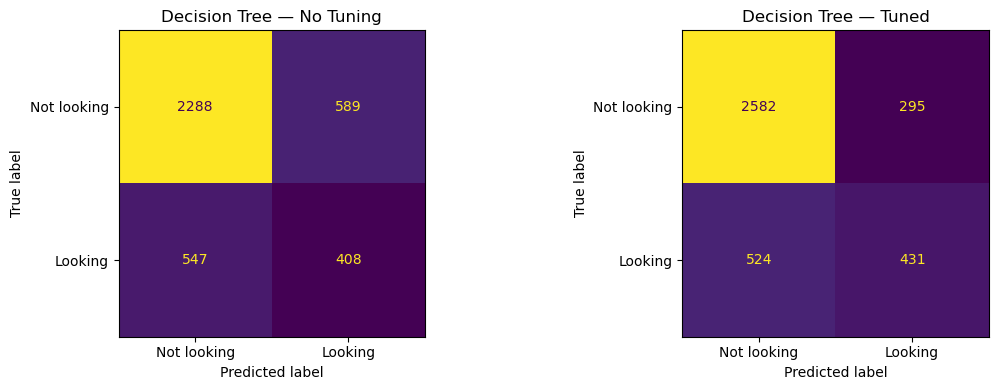

In [7]:
# Confusion matrix for tuned Decision Tree
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, y_pred, title in zip(axes, 
                              [y_pred_no_tuning, y_pred_tuned],
                              ['Decision Tree — No Tuning', 'Decision Tree — Tuned']):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not looking', 'Looking'])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(title)

plt.tight_layout()
plt.show()